# Exploratory Data Analysis (EDA)

Este notebook explora la data limpia para encontrar patrones, distribuciones y relaciones.

Objetivos principales:
- Entender la distribución de las puntuaciones de ansiedad
- Analizar diferencias demográficas
- Explorar relaciones entre síntomas
- Obtener información útil para futuros modelos

### Setup del proyecto

In [1]:
# Setup project root
import sys
from pathlib import Path

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Asegura que src esté en sys.path
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

### Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import MaxNLocator, PercentFormatter
from src.config import DATA_PROCESSED, OUTPUTS_FIGURES
from src.data_loader import load_excel
from src.utils import (
    CATEGORY_ORDER,
    CATEGORY_PALETTE,
    GENDER_PALETTE,
    SCORE_BANDS,
    bai_label_map,
    build_category_counts,
    get_bai_columns,
    polish_axes,
    save_plot as save_plot_to_path,
    wrap_label,
)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#FAFAFA",
    "axes.edgecolor": "#D6D6D6",
    "axes.labelcolor": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "axes.titleweight": "bold",
})


def save_plot(fig, filename, dpi=180):
    return save_plot_to_path(fig, filename, OUTPUTS_FIGURES, dpi=dpi)

### Cargar data limpia

In [3]:
df = load_excel(DATA_PROCESSED)
df.head()

,id,age,category,gender,totalScore,BAI_1,BAI_2,BAI_3,BAI_4,BAI_5,...,BAI_12,BAI_13,BAI_14,BAI_15,BAI_16,BAI_17,BAI_18,BAI_19,BAI_20,BAI_21
0,024ccc066e5f36803f8861b9ee3d94888e5370faed41a9...,24,LOW,M,11,1,2,0,0,2,...,0,0,0,0,0,1,0,0,0,2
1,02f2a803fa9512cbee77681b62aec389336d01bf56e54b...,19,LOW,M,15,2,3,0,2,1,...,0,0,0,1,0,0,1,0,0,2
2,044a25cf19eab34fffd83bdd006ce8338150351ac18ebf...,23,LOW,M,16,2,2,0,2,2,...,0,0,1,0,0,2,0,0,0,1
3,05590f956566724748711d0b68f1b44f3fabfc87cab7cf...,25,LOW,M,4,0,0,0,1,1,...,0,0,0,0,0,0,1,0,0,0
4,0ba67bab767aadf47f4be2743015846e30a32459939c76...,23,LOW,M,10,0,1,0,2,2,...,0,0,0,0,1,0,1,0,0,0


## Parte 1 - DISTRIBUCIÓN DE ANSIEDAD

### Distribución de score

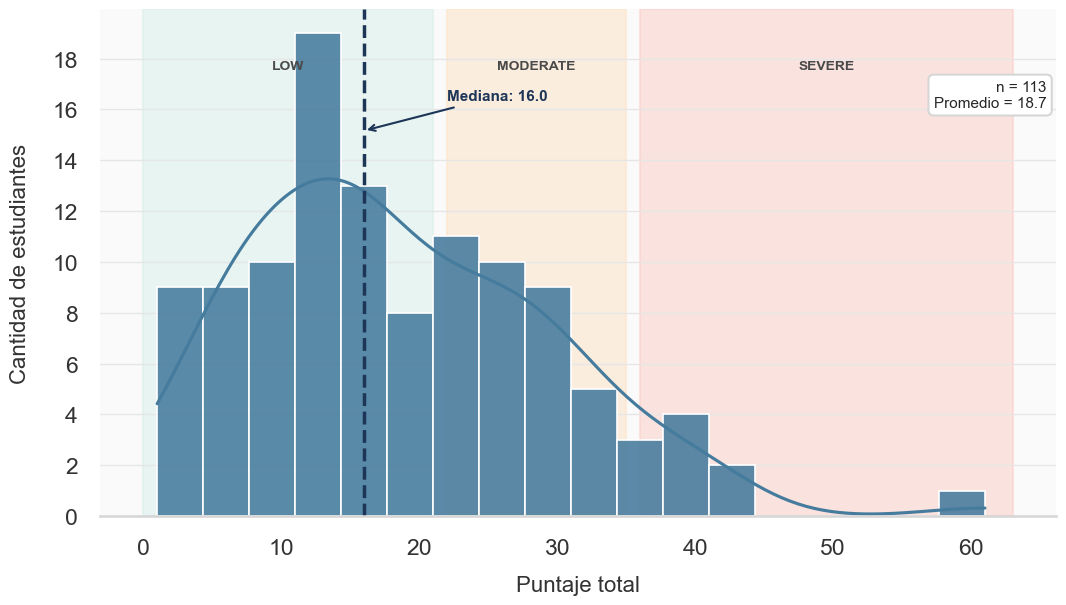

In [4]:
fig, ax = plt.subplots(figsize=(11, 6.4))
score_mean = df["totalScore"].mean()
score_median = df["totalScore"].median()

for start, end, label, color in SCORE_BANDS:
    ax.axvspan(start, end, color=color, alpha=0.55, zorder=0)
    ax.text(
        (start + end) / 2,
        0.90,
        label,
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold",
        color="#4A4A4A",
    )

sns.histplot(
    data=df,
    x="totalScore",
    bins=18,
    kde=True,
    color="#457B9D",
    edgecolor="white",
    linewidth=1.2,
    alpha=0.88,
    ax=ax,
)

ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.axvline(score_median, color="#1D3557", linewidth=2.5, linestyle="--")
ax.annotate(
    f"Mediana: {score_median:.1f}",
    xy=(score_median, ax.get_ylim()[1] * 0.76),
    xytext=(score_median + 6, ax.get_ylim()[1] * 0.82),
    arrowprops={"arrowstyle": "->", "color": "#1D3557", "lw": 1.5},
    color="#1D3557",
    fontsize=11,
    fontweight="bold",
)
ax.text(
    0.99,
    0.86,
    f"n = {len(df)}\nPromedio = {score_mean:.1f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#D6D6D6"},
)

ax.set_xlabel("Puntaje total", fontsize=16, labelpad=12)
ax.set_ylabel("Cantidad de estudiantes", fontsize=16, labelpad=16)
ax.tick_params(axis="both", pad=8)
polish_axes(ax)
save_plot(fig, "score_distribution.png")
plt.show()

### Conteo por nivel de ansiedad

In [5]:
df['category'].value_counts()

category
LOW         71
MODERATE    34
SEVERE       8
Name: count, dtype: int64

### Gráfico de barras

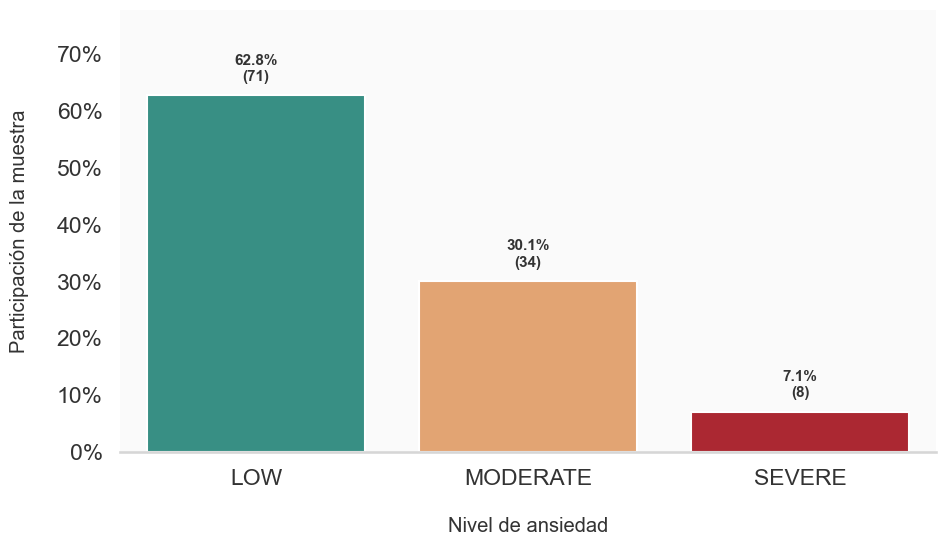

In [6]:
category_counts = build_category_counts(df, CATEGORY_ORDER)

fig, ax = plt.subplots(figsize=(9.8, 5.8))
sns.barplot(
    data=category_counts,
    x="category",
    y="percentage",
    order=CATEGORY_ORDER,
    palette=CATEGORY_PALETTE,
    hue="category",
    legend=False,
    ax=ax,
)

for patch, row in zip(ax.patches, category_counts.itertuples()):
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_height()
    ax.text(
        x,
        y + 2,
        f"{row.percentage:.1f}%\n({int(row.count)})",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color="#333333",
    )

ax.set_ylim(0, max(category_counts["percentage"]) + 15)
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.set_xlabel("Nivel de ansiedad", fontsize=14.5, labelpad=20)
ax.set_ylabel("Participación de la muestra", fontsize=14.5, labelpad=20)
ax.grid(False)
ax.set_title("")
sns.despine(ax=ax, left=True, bottom=False)
save_plot(fig, "anxiety_distribution.png")
plt.show()

## Parte 2 - DEMOGRAFÍA

### Ansiedad por género

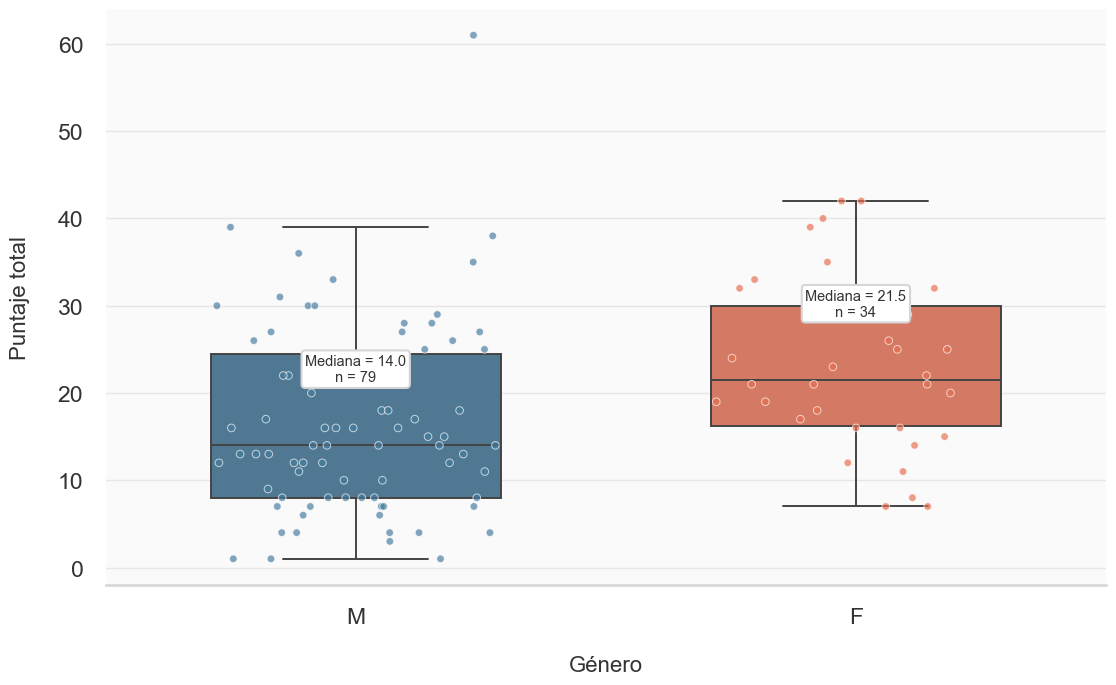

In [7]:
fig, ax = plt.subplots(figsize=(11.5, 7.2))
sns.boxplot(
    data=df,
    x="gender",
    y="totalScore",
    order=["M", "F"],
    hue="gender",
    palette=GENDER_PALETTE,
    width=0.58,
    linewidth=1.4,
    fliersize=0,
    legend=False,
    ax=ax,
)
sns.stripplot(
    data=df,
    x="gender",
    y="totalScore",
    order=["M", "F"],
    hue="gender",
    palette=GENDER_PALETTE,
    dodge=False,
    jitter=0.28,
    alpha=0.68,
    size=5.5,
    edgecolor="white",
    linewidth=0.7,
    legend=False,
    ax=ax,
)

summary = df.groupby("gender")["totalScore"].agg(["count", "median"]).reindex(["M", "F"])
for x, (gender, row) in enumerate(summary.iterrows()):
    ax.text(
        x,
        row["median"] + 7.0,
        f"Mediana = {row['median']:.1f}\nn = {int(row['count'])}",
        ha="center",
        va="bottom",
        fontsize=10.5,
        color="#333333",
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "#D6D6D6"},
    )

ax.set_xlabel("Género", fontsize=16, labelpad=20)
ax.set_ylabel("Puntaje total", fontsize=16, labelpad=20)
polish_axes(ax)
save_plot(fig, "anxiety_by_gender.png")
plt.show()

### Edad vs puntaje de ansiedad

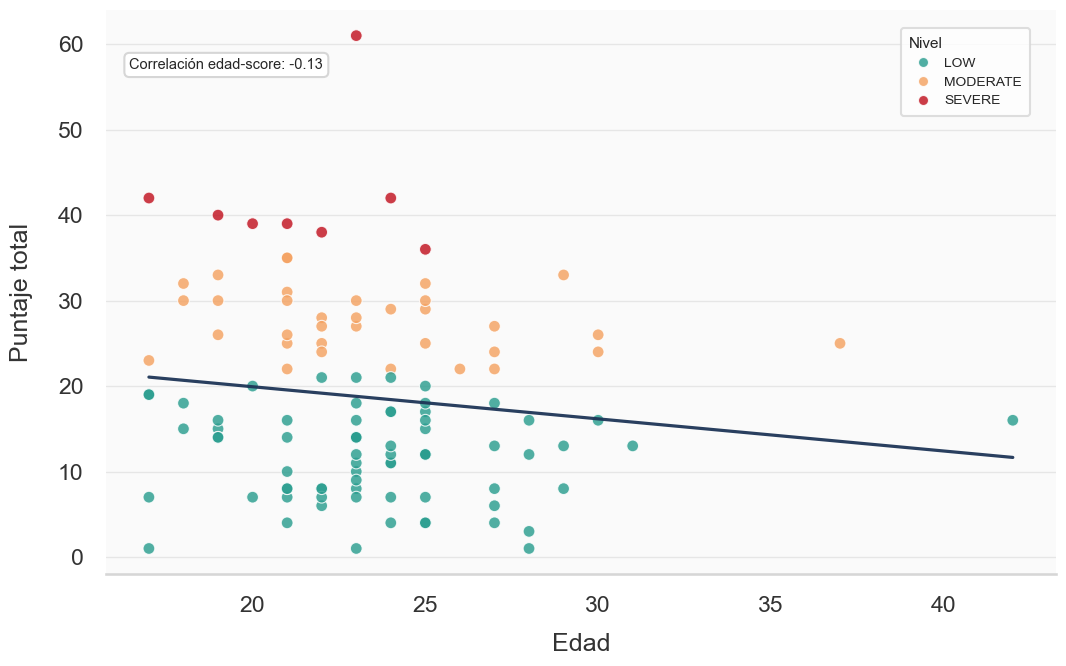

In [8]:
fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(
    data=df,
    x="age",
    y="totalScore",
    hue="category",
    hue_order=CATEGORY_ORDER,
    palette=CATEGORY_PALETTE,
    s=72,
    alpha=0.82,
    edgecolor="white",
    linewidth=0.8,
    ax=ax,
)
sns.regplot(
    data=df,
    x="age",
    y="totalScore",
    scatter=False,
    ci=None,
    color="#1D3557",
    line_kws={"linewidth": 2.3, "alpha": 0.95},
    ax=ax,
)

corr = df[["age", "totalScore"]].corr().iloc[0, 1]
ax.text(
    0.025,
    0.915,
    f"Correlación edad-score: {corr:.2f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10.5,
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#D6D6D6"},
)
legend = ax.legend(
    title="Nivel",
    frameon=True,
    facecolor="white",
    edgecolor="#D6D6D6",
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    borderpad=0.6,
    labelspacing=0.45,
    handletextpad=0.5,
    markerscale=0.85,
    fontsize=10,
    title_fontsize=11,
)
legend._legend_box.align = "left"

ax.set_xlabel("Edad", labelpad=12)
ax.set_ylabel("Puntaje total", labelpad=18)
ax.tick_params(axis="both", pad=8)
polish_axes(ax)
save_plot(fig, "age_vs_anxiety.png")
plt.show()

## Parte 3 - Correlaciones

### Correlación entre preguntas BAI

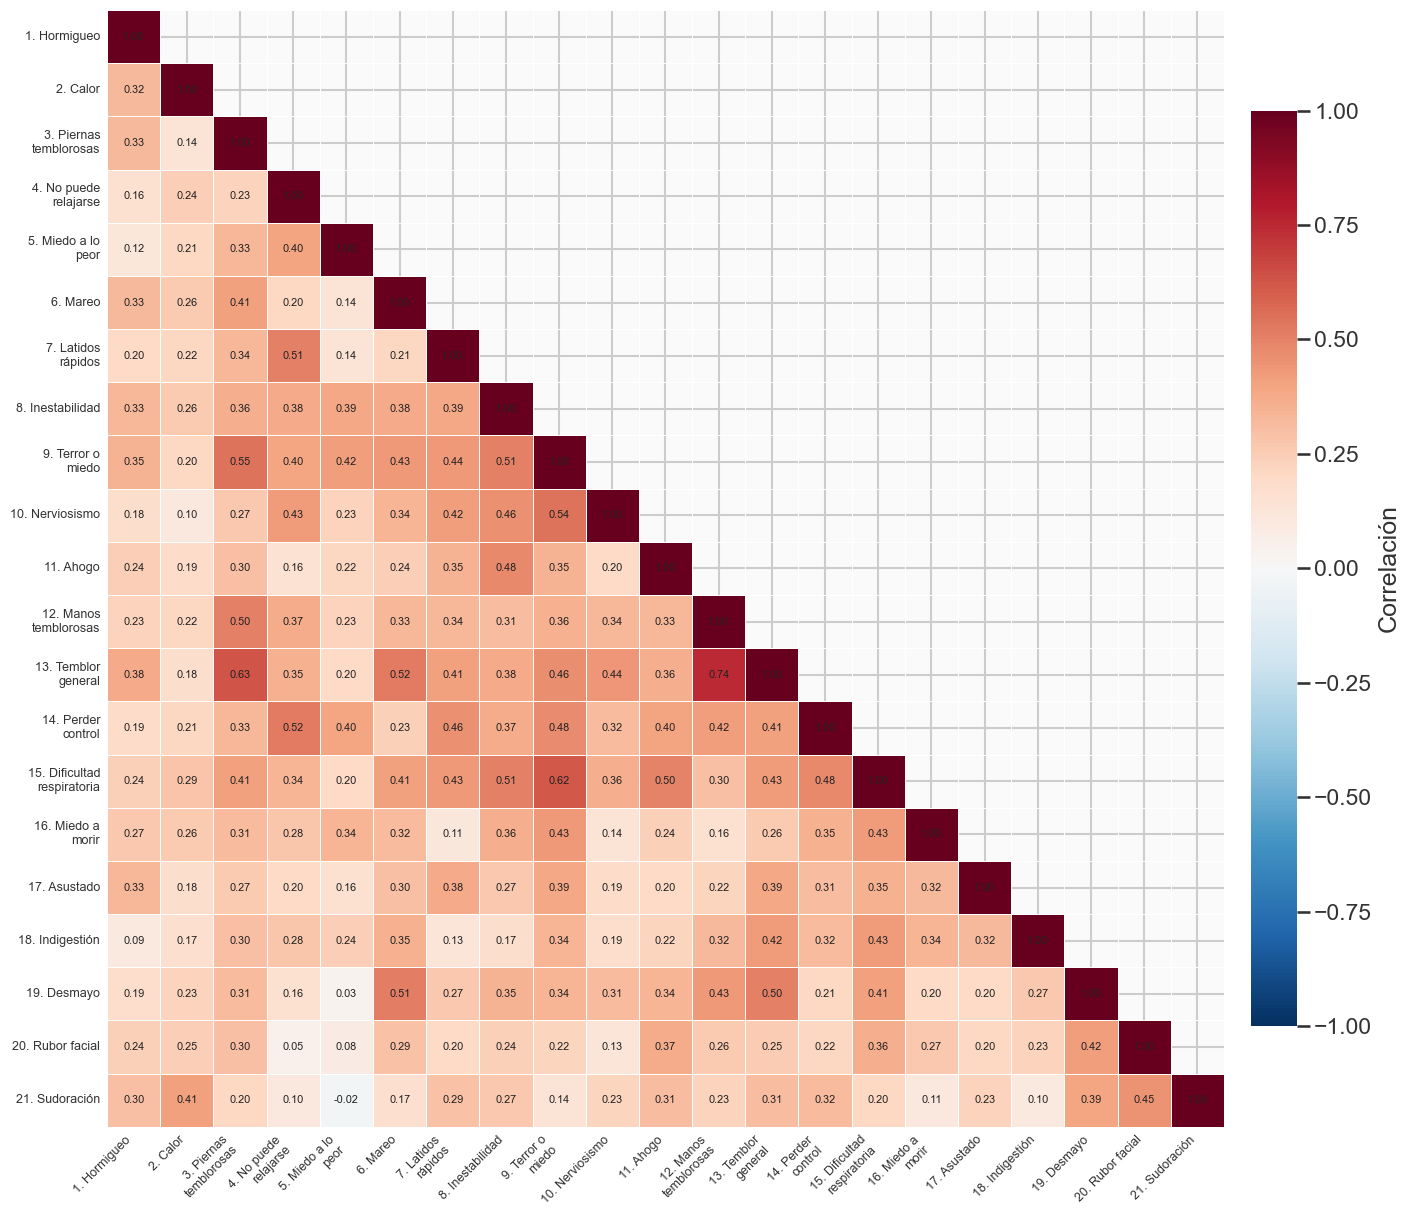

In [9]:
bai_cols = get_bai_columns(df)
bai_labels = bai_label_map(bai_cols)
heatmap_labels = bai_label_map(bai_cols, short=True)

corr_matrix = df[bai_cols].corr().rename(index=heatmap_labels, columns=heatmap_labels)
wrapped_labels = [wrap_label(label, width=16) for label in corr_matrix.columns]
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(15, 12.5))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.45,
    linecolor="white",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7.8, "color": "#222222"},
    cbar_kws={"label": "Correlación", "shrink": 0.82, "pad": 0.02},
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(wrapped_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(wrapped_labels, rotation=0, fontsize=9)
ax.tick_params(axis="both", length=0, pad=5)

save_plot(fig, "bai_correlation_heatmap.png")
plt.show()

### Correlación con score total

In [10]:
corr_with_score = (
    df[bai_cols + ["totalScore"]]
    .corr()["totalScore"]
    .sort_values(ascending=False)
)

corr_with_score_labeled = corr_with_score.rename(index=lambda col: bai_labels.get(col, col))
corr_with_score_labeled

totalScore                                  1.000000
BAI_9: Terror o miedo                       0.738511
BAI_13: Temblor general                     0.730560
BAI_15: Dificultad para respirar            0.705755
BAI_8: Inestabilidad                        0.674356
BAI_14: Miedo a perder el control           0.662292
BAI_3: Temblor en las piernas               0.636196
BAI_12: Temblor en las manos                0.621027
BAI_6: Mareo o aturdimiento                 0.595800
BAI_7: Latidos fuertes o rápidos            0.593942
BAI_4: Incapacidad para relajarse           0.571197
BAI_11: Sensación de ahogo                  0.570198
BAI_10: Nerviosismo                         0.567087
BAI_19: Sensación de desmayo                0.559659
BAI_16: Miedo a morir                       0.536062
BAI_17: Asustado                            0.523451
BAI_18: Indigestión o malestar abdominal    0.514109
BAI_1: Entumecimiento u hormigueo           0.489906
BAI_20: Rubor facial                        0.

## Parte 4 - TOP SÍNTOMAS

### Top síntomas asociados

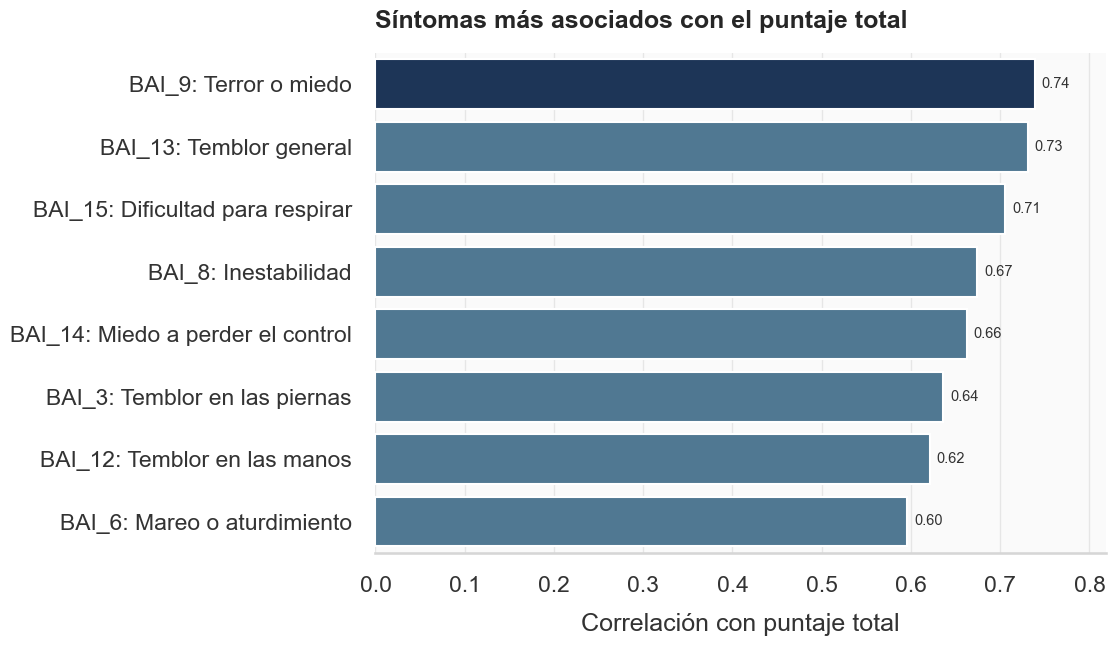

In [11]:
top_symptoms = corr_with_score.drop("totalScore").head(8)
top_symptoms_plot = top_symptoms
top_symptoms_labels = [wrap_label(bai_labels[col], width=34) for col in top_symptoms_plot.index]

fig, ax = plt.subplots(figsize=(11.5, 6.8))
sns.barplot(
    x=top_symptoms_plot.values,
    y=top_symptoms_labels,
    color="#457B9D",
    ax=ax,
)

ax.patches[0].set_facecolor("#1D3557")
ax.bar_label(
    ax.containers[0],
    labels=[f"{value:.2f}" for value in top_symptoms_plot.values],
    padding=5,
    fontsize=10.5,
    color="#333333",
)

ax.set_xlim(0, min(1, top_symptoms_plot.max() + 0.08))
ax.set_title("Síntomas más asociados con el puntaje total", loc="left", pad=18)
ax.set_xlabel("Correlación con puntaje total", labelpad=12)
ax.set_ylabel("")
ax.grid(axis="x", color="#E6E6E6", linewidth=1)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="both", pad=8)
sns.despine(ax=ax, left=True, bottom=False)

save_plot(fig, "top_symptoms.png")
plt.show()